# **Laboratorio 8 - Introducción a Señales Biomédicas**
***Alumna: Nataly Deledesma Romero***

In [20]:
!pip install neurokit2 -q

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

In [22]:
from scipy.signal import (
    firwin, lfilter, butter, filtfilt,
    medfilt, iirnotch, resample, correlate
)

In [23]:
plt.rcParams.update({'figure.figsize': (14, 4),'axes.grid': True,'grid.alpha': 0.3,'font.size': 11})

# **Ejercicio** 1

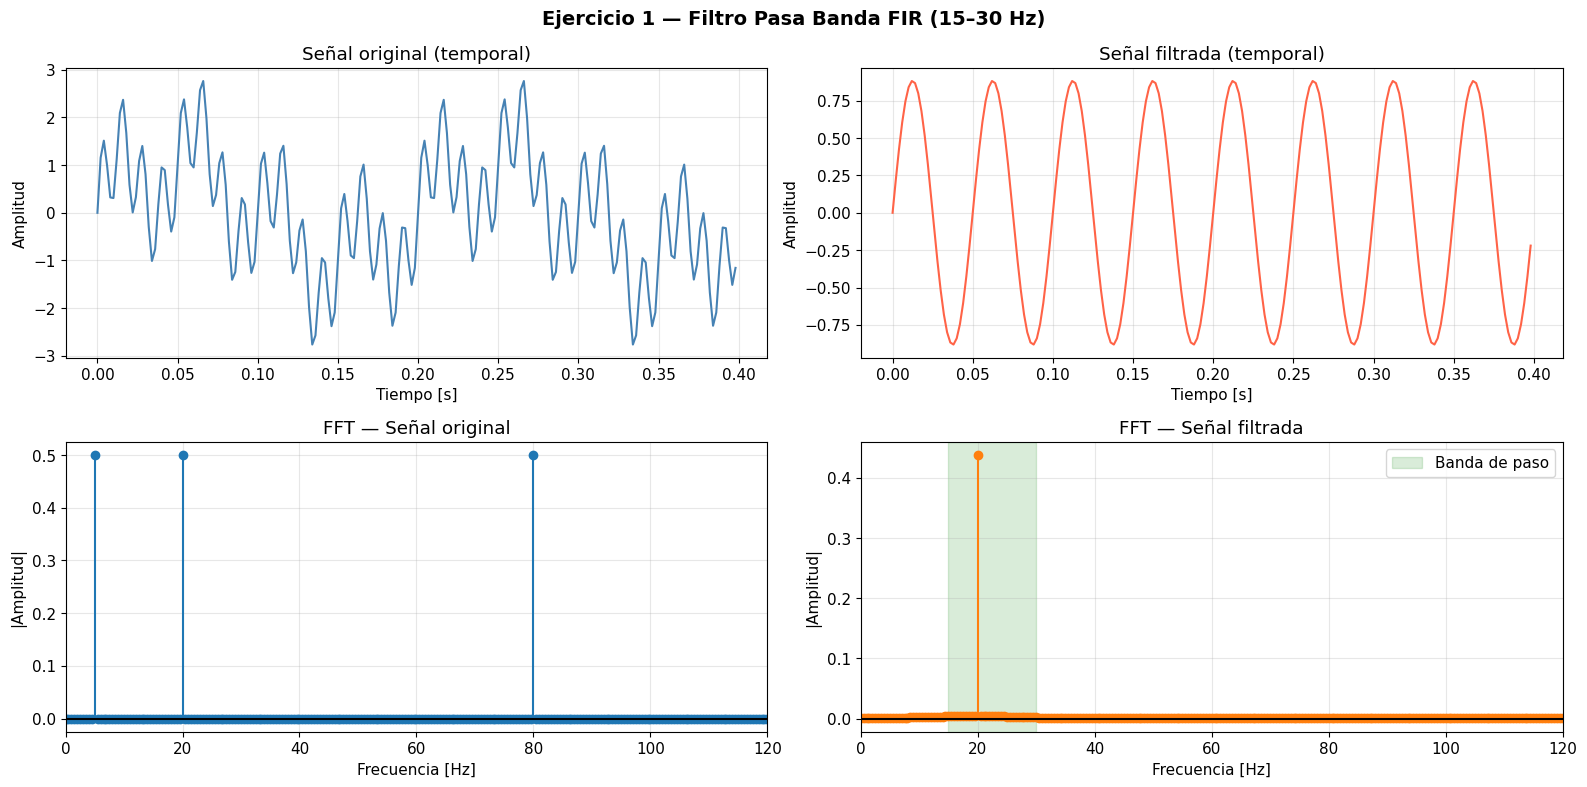

Solo el componente de 20 Hz queda en la salida.


In [24]:
# Parámetros
fs   = 500
dur  = 2.0
t    = np.linspace(0, dur, int(fs * dur), endpoint=False)

f1, f2, f3 = 5, 20, 80
bp_low, bp_high = 15, 30

# Señal compuesta
s1     = np.sin(2 * np.pi * f1 * t)
s2     = np.sin(2 * np.pi * f2 * t)
s3     = np.sin(2 * np.pi * f3 * t)
signal = s1 + s2 + s3

# Diseño del filtro FIR
N        = 101
fir      = firwin(N, [bp_low, bp_high], pass_zero=False, fs=fs)
filtered = filtfilt(fir, 1.0, signal)

# FFT helper
def compute_fft(x, fs):
    N = len(x)
    Y = np.abs(np.fft.rfft(x)) / N
    f = np.fft.rfftfreq(N, 1/fs)
    return f, Y

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Ejercicio 1 — Filtro Pasa Banda FIR (15–30 Hz)', fontsize=14, fontweight='bold')

axes[0, 0].plot(t[:200], signal[:200], color='steelblue')
axes[0, 0].set_title('Señal original (temporal)')
axes[0, 0].set_xlabel('Tiempo [s]')
axes[0, 0].set_ylabel('Amplitud')

axes[0, 1].plot(t[:200], filtered[:200], color='tomato')
axes[0, 1].set_title('Señal filtrada (temporal)')
axes[0, 1].set_xlabel('Tiempo [s]')
axes[0, 1].set_ylabel('Amplitud')

f, Y = compute_fft(signal, fs)
axes[1, 0].stem(f, Y, linefmt='C0-', markerfmt='C0o', basefmt='k-')
axes[1, 0].set_title('FFT — Señal original')
axes[1, 0].set_xlabel('Frecuencia [Hz]')
axes[1, 0].set_ylabel('|Amplitud|')
axes[1, 0].set_xlim(0, 120)

f, Yf = compute_fft(filtered, fs)
axes[1, 1].stem(f, Yf, linefmt='C1-', markerfmt='C1o', basefmt='k-')
axes[1, 1].set_title('FFT — Señal filtrada')
axes[1, 1].set_xlabel('Frecuencia [Hz]')
axes[1, 1].set_ylabel('|Amplitud|')
axes[1, 1].set_xlim(0, 120)
axes[1, 1].axvspan(bp_low, bp_high, alpha=0.15, color='green', label='Banda de paso')
axes[1, 1].legend()

plt.tight_layout()
plt.show()
print('Solo el componente de 20 Hz queda en la salida.')

# **Ejercicio 2**

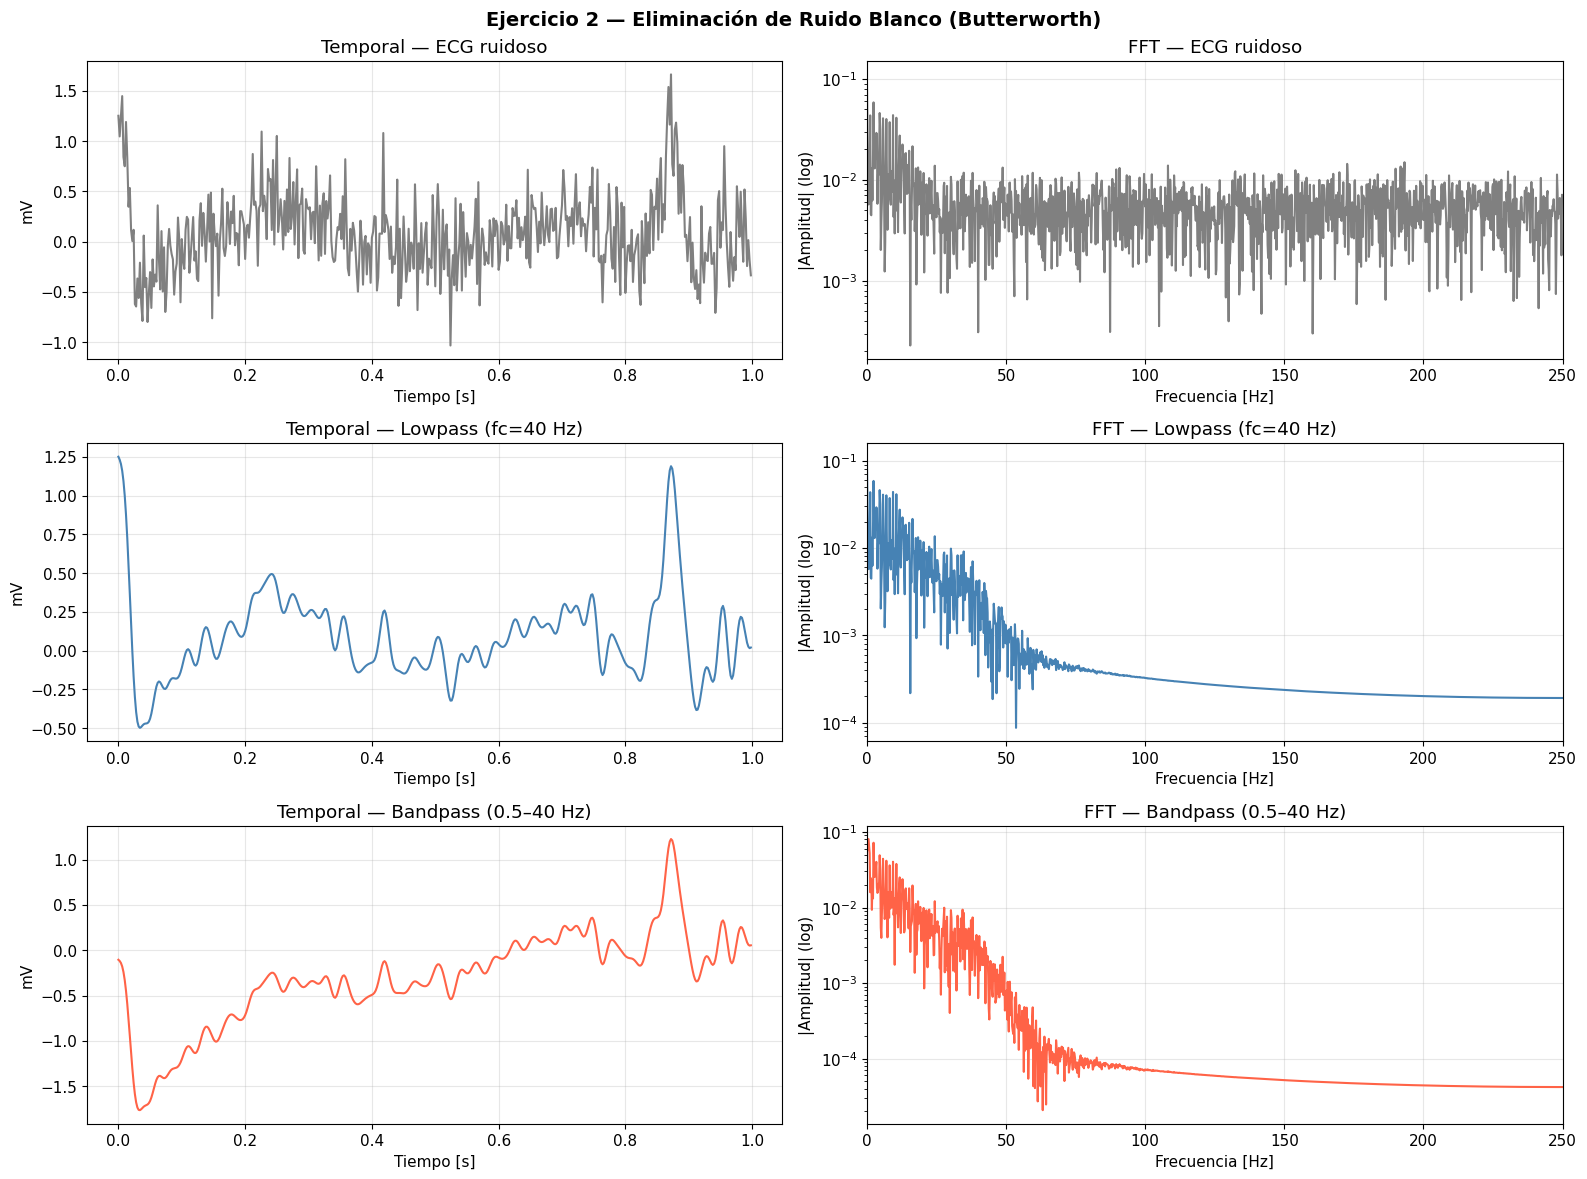

El bandpass (0.5–40 Hz) también elimina deriva de línea base.


In [25]:
# Parámetros
fs_ecg  = 500
dur_ecg = 5
ecg_clean = nk.ecg_simulate(duration=dur_ecg, sampling_rate=fs_ecg, heart_rate=70, noise=0)

# Añadir ruido blanco
np.random.seed(42)
noise     = np.random.normal(0, 0.3, len(ecg_clean))
ecg_noisy = ecg_clean + noise

t_ecg = np.linspace(0, dur_ecg, len(ecg_clean), endpoint=False)

# Filtro Lowpass Butterworth
b_lp, a_lp = butter(4, 40, btype='low', fs=fs_ecg)
ecg_lp     = filtfilt(b_lp, a_lp, ecg_noisy)

# Filtro Bandpass Butterworth
b_bp, a_bp = butter(4, [0.5, 40], btype='band', fs=fs_ecg)
ecg_bp     = filtfilt(b_bp, a_bp, ecg_noisy)

# Visualización
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Ejercicio 2 — Eliminación de Ruido Blanco (Butterworth)', fontsize=14, fontweight='bold')

labels = [('ECG ruidoso', ecg_noisy,'gray'),
          ('Lowpass (fc=40 Hz)', ecg_lp,'steelblue'),
          ('Bandpass (0.5–40 Hz)', ecg_bp,'tomato')]

for i, (label, sig, color) in enumerate(labels):
    axes[i, 0].plot(t_ecg[:500], sig[:500], color=color)
    axes[i, 0].set_title(f'Temporal — {label}')
    axes[i, 0].set_xlabel('Tiempo [s]')
    axes[i, 0].set_ylabel('mV')

    f, Y = compute_fft(sig, fs_ecg)
    axes[i, 1].semilogy(f, Y + 1e-6, color=color)
    axes[i, 1].set_title(f'FFT — {label}')
    axes[i, 1].set_xlabel('Frecuencia [Hz]')
    axes[i, 1].set_ylabel('|Amplitud| (log)')
    axes[i, 1].set_xlim(0, 250)

plt.tight_layout()
plt.show()
print('El bandpass (0.5–40 Hz) también elimina deriva de línea base.')

# **Ejercicio 3**

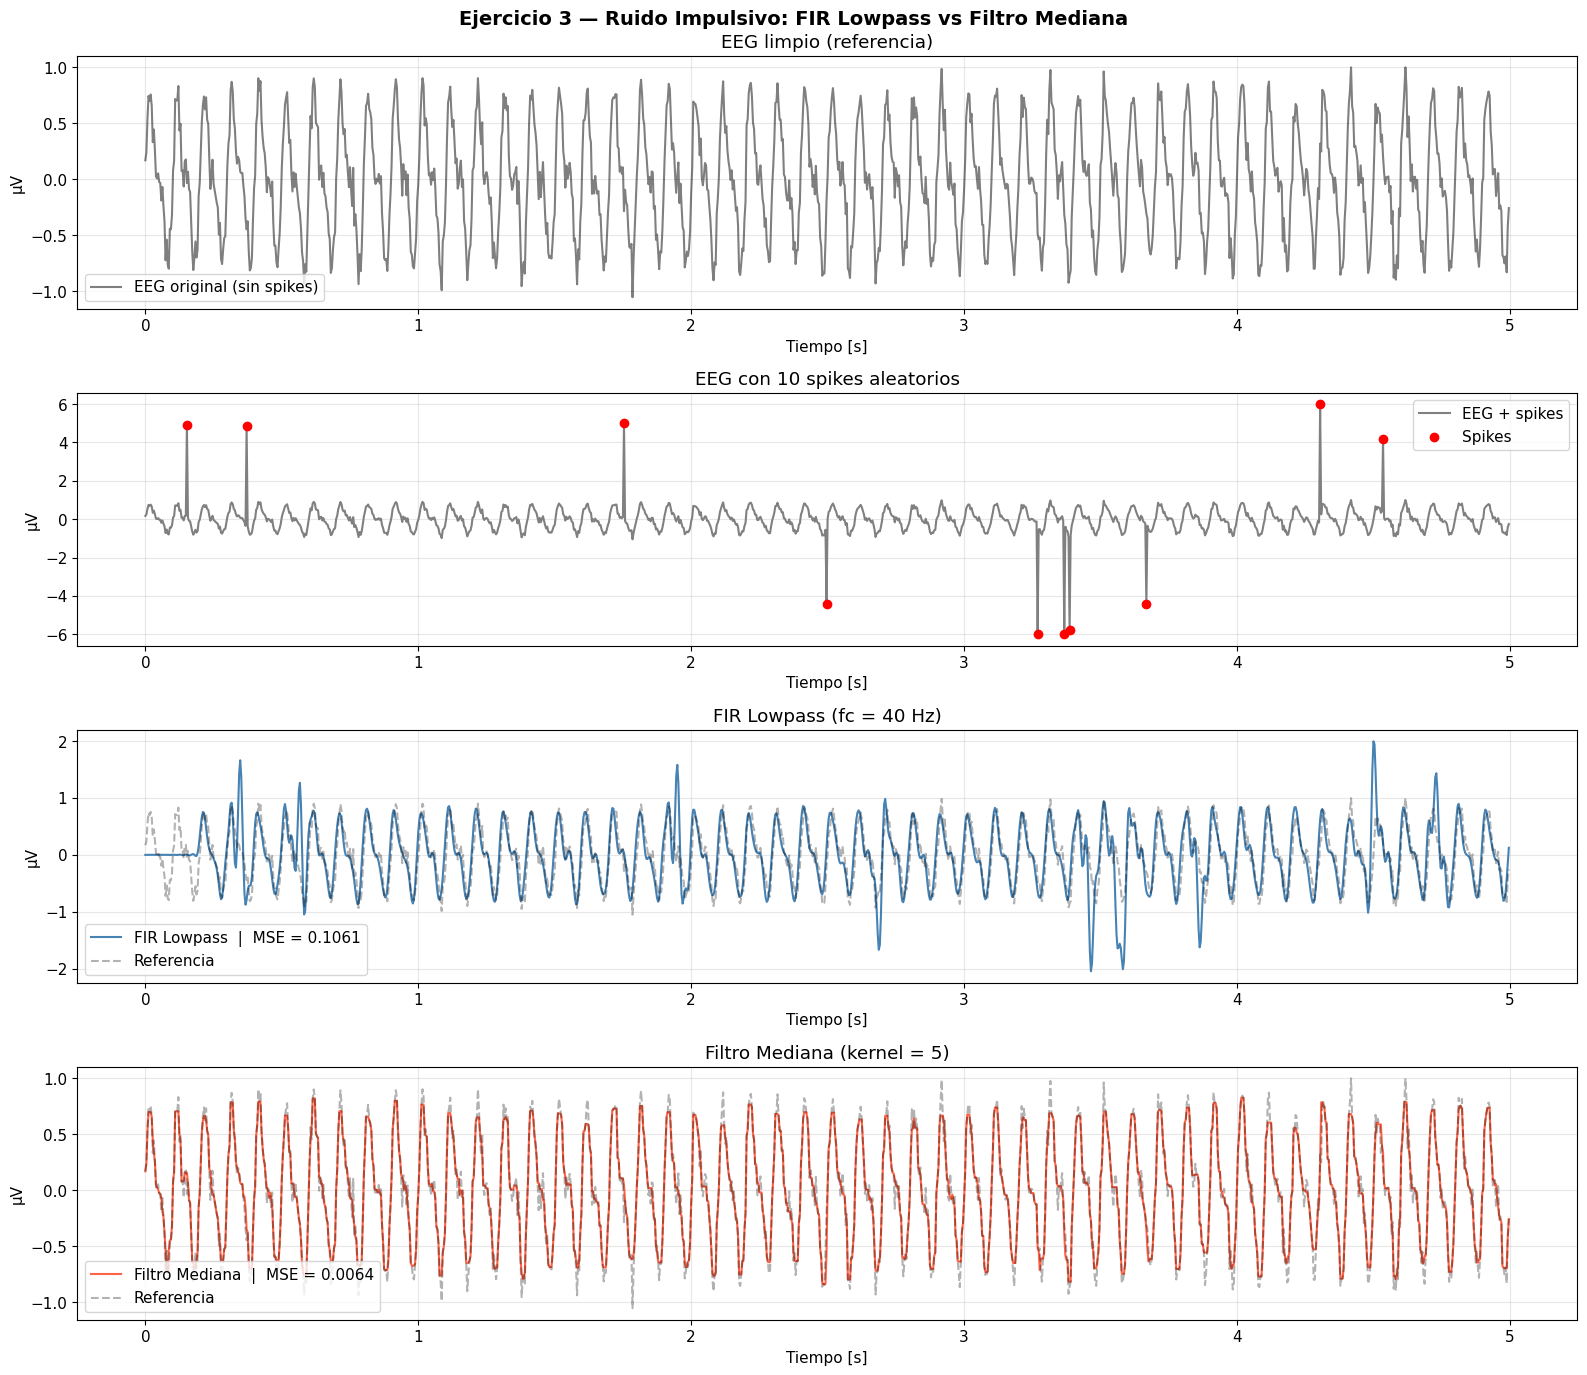

MSE — FIR Lowpass  : 0.1061
MSE — Filtro Mediana: 0.0064

 Filtro Mediana obtiene menor MSE frente a ruido impulsivo.


In [26]:
# Parámetros
fs_eeg  = 256
dur_eeg = 5
t_eeg   = np.linspace(0, dur_eeg, int(fs_eeg * dur_eeg), endpoint=False)

# EEG simulado
np.random.seed(7)
eeg = (0.6 * np.sin(2 * np.pi * 10 * t_eeg) +
       0.3 * np.sin(2 * np.pi * 20 * t_eeg) +
       0.1 * np.random.randn(len(t_eeg)))

# Añadir 10 spikes aleatorios
spike_idx = np.random.choice(len(eeg), 10, replace=False)
eeg_spiky = eeg.copy()
for idx in spike_idx:
    eeg_spiky[idx] = np.random.choice([-5, 5]) * np.random.uniform(0.8, 1.2)

# Filtro FIR Lowpass
fir_lp     = firwin(101, 40, fs=fs_eeg)
eeg_fir    = lfilter(fir_lp, 1.0, eeg_spiky)

# Filtro Mediana
eeg_median = medfilt(eeg_spiky, 5)

# Métricas MSE
mse_fir = np.mean((eeg - eeg_fir)    ** 2)
mse_median = np.mean((eeg - eeg_median) ** 2)

# Visualización
fig, axes = plt.subplots(4, 1, figsize=(16, 14))
fig.suptitle('Ejercicio 3 — Ruido Impulsivo: FIR Lowpass vs Filtro Mediana', fontsize=14, fontweight='bold')

axes[0].plot(t_eeg, eeg, 'k', alpha=0.5, label='EEG original (sin spikes)')
axes[0].set_title('EEG limpio (referencia)'); axes[0].legend()

axes[1].plot(t_eeg, eeg_spiky, color='gray', label='EEG + spikes')
axes[1].scatter(t_eeg[spike_idx], eeg_spiky[spike_idx], color='red', zorder=5, label='Spikes')
axes[1].set_title('EEG con 10 spikes aleatorios'); axes[1].legend()

axes[2].plot(t_eeg, eeg_fir, color='steelblue', label=f'FIR Lowpass  |  MSE = {mse_fir:.4f}')
axes[2].plot(t_eeg, eeg, 'k--', alpha=0.3, label='Referencia')
axes[2].set_title('FIR Lowpass (fc = 40 Hz)'); axes[2].legend()

axes[3].plot(t_eeg, eeg_median, color='tomato', label=f'Filtro Mediana  |  MSE = {mse_median:.4f}')
axes[3].plot(t_eeg, eeg, 'k--', alpha=0.3, label='Referencia')
axes[3].set_title('Filtro Mediana (kernel = 5)'); axes[3].legend()

for ax in axes:ax.set_xlabel('Tiempo [s]'); ax.set_ylabel('μV')

plt.tight_layout()
plt.show()

print(f'MSE — FIR Lowpass  : {mse_fir:.4f}')
print(f'MSE — Filtro Mediana: {mse_median:.4f}')
winner = 'Filtro Mediana' if mse_median < mse_fir else 'FIR Lowpass'
print(f'\n {winner} obtiene menor MSE frente a ruido impulsivo.')

El filtro mediana funciona mejor porque un spike es un valor extremo aislado y la mediana de una ventana de 5 muestras es 0.3, entonces el valor anómalo simplemente queda fuera de la mediana y se descarta. En cambio, el FIR es un promedio ponderado lineal, y un valor de 5.8 arrastra el promedio hacia arriba inevitablemente, distorsionando las muestras vecinas.

# **Ejercicio 4**

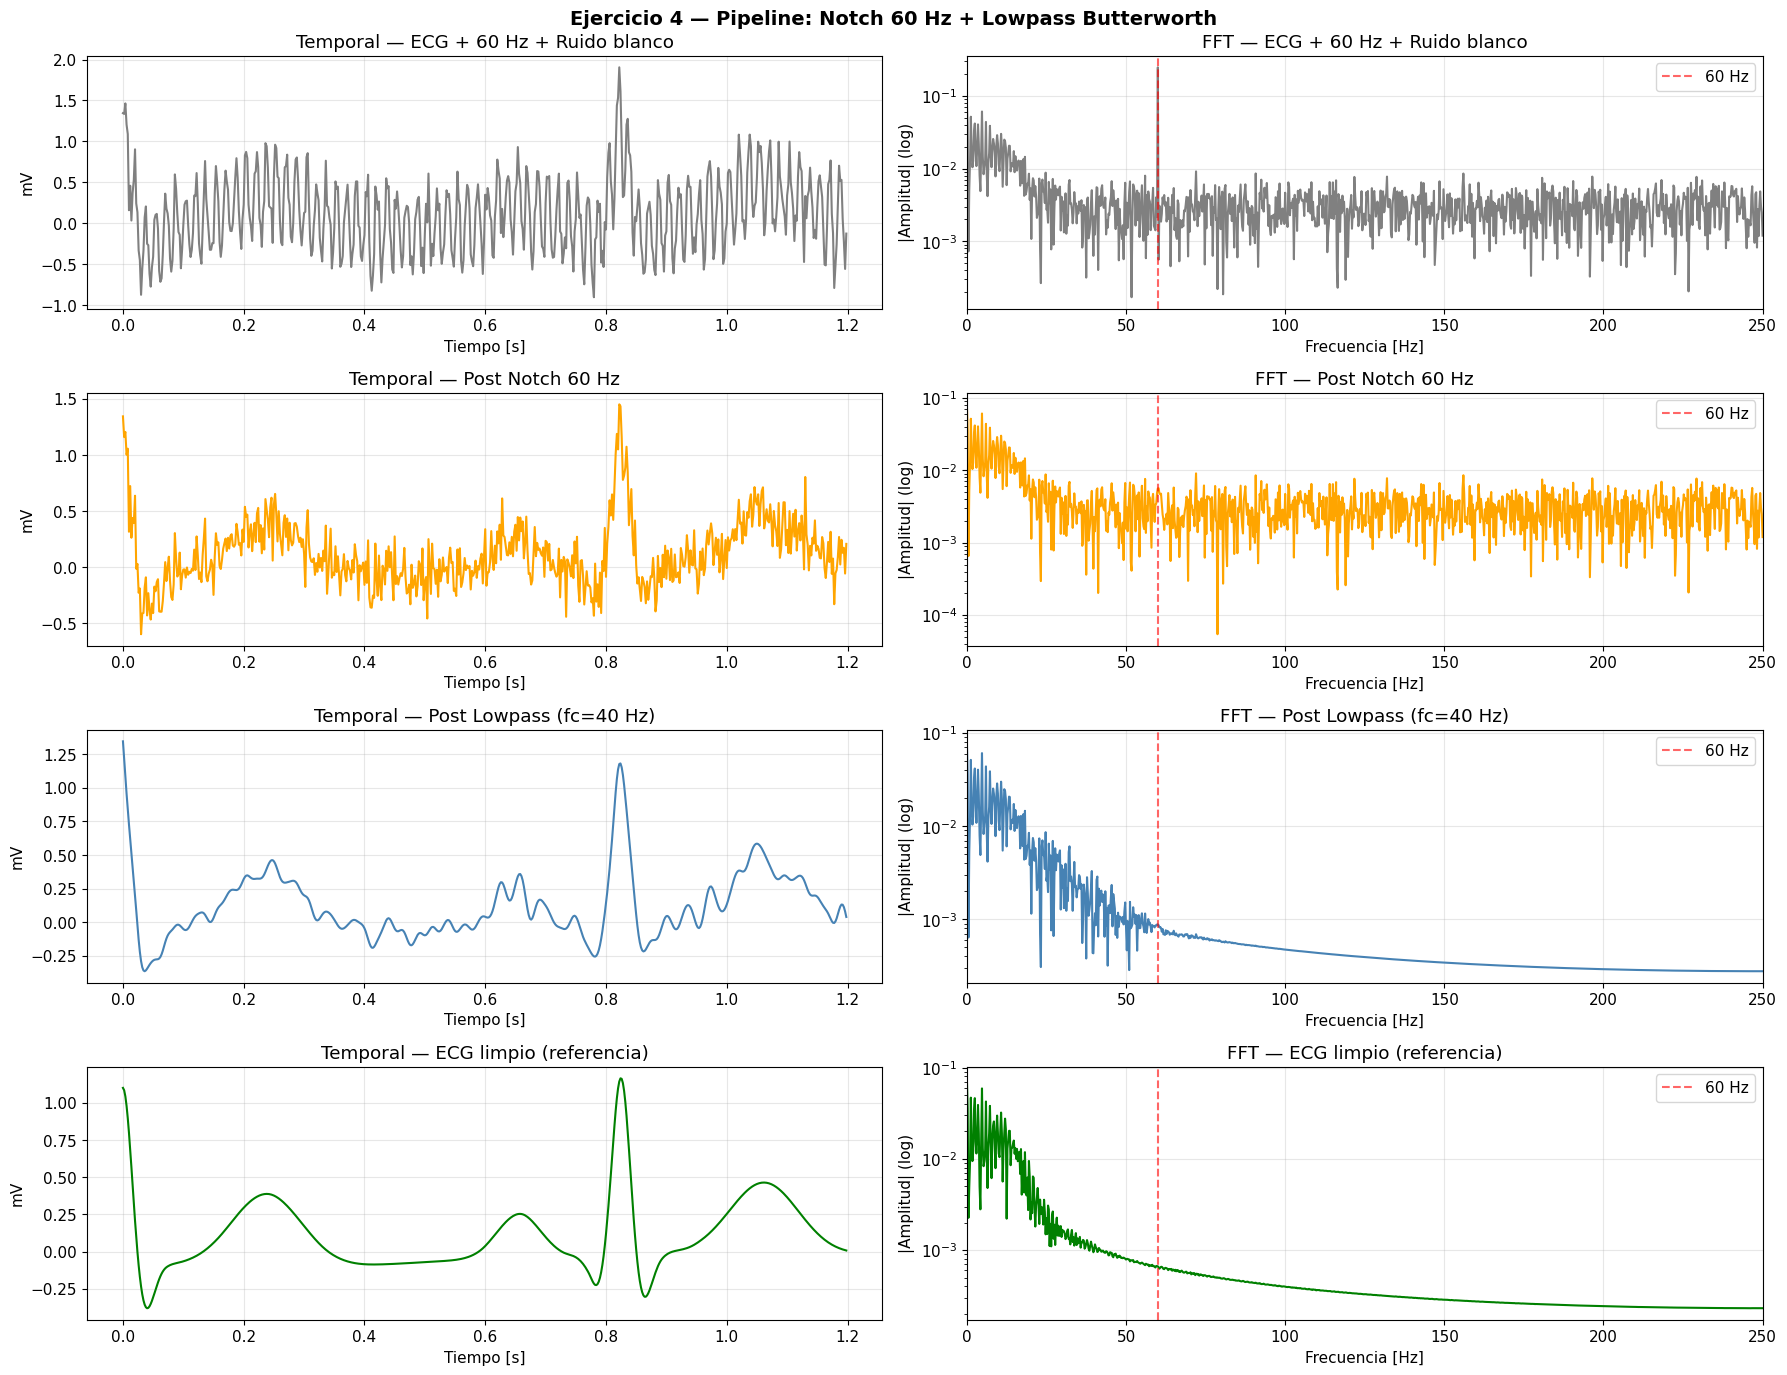

MSE del pipeline vs ECG limpio: 0.00336
El pico de 60 Hz desaparece tras el notch.
El lowpass elimina el ruido de alta frecuencia residual.


In [27]:
# Parámetros
fs_ecg2 = 500
dur2 = 4
t2 = np.linspace(0, dur2, int(fs_ecg2 * dur2), endpoint=False)

# ECG sintético
ecg2 = nk.ecg_simulate(duration=dur2, sampling_rate=fs_ecg2, heart_rate=72, noise=0)

# Interferencias
np.random.seed(1)
noise_60hz = 0.5 * np.sin(2 * np.pi * 60 * t2)
noise_wn   = np.random.normal(0, 0.15, len(ecg2))
ecg_noisy2 = ecg2 + noise_60hz + noise_wn

# PIPELINE
# Etapa 1: Notch 60 Hz
b_notch, a_notch = iirnotch(60, 30, fs_ecg2)
ecg_notch = filtfilt(b_notch, a_notch, ecg_noisy2)

# Etapa 2: Butterworth Lowpass fc = 40 Hz
b_lp2, a_lp2 = butter(4, 40, btype='low', fs=fs_ecg2)
ecg_pipeline = filtfilt(b_lp2, a_lp2, ecg_notch)

# Visualización
fig, axes = plt.subplots(4, 2, figsize=(18, 14))
fig.suptitle('Ejercicio 4 — Pipeline: Notch 60 Hz + Lowpass Butterworth', fontsize=14, fontweight='bold')

stages = [
    ('ECG + 60 Hz + Ruido blanco', ecg_noisy2, 'gray'),
    ('Post Notch 60 Hz', ecg_notch, 'orange'),
    ('Post Lowpass (fc=40 Hz)', ecg_pipeline, 'steelblue'),
    ('ECG limpio (referencia)', ecg2, 'green'),
]

for i, (label, sig, color) in enumerate(stages):
    axes[i, 0].plot(t2[:600], sig[:600], color=color)
    axes[i, 0].set_title(f'Temporal — {label}')
    axes[i, 0].set_xlabel('Tiempo [s]')
    axes[i, 0].set_ylabel('mV')

    f, Y = compute_fft(sig, fs_ecg2)
    axes[i, 1].semilogy(f, Y + 1e-6, color=color)
    axes[i, 1].axvline(60, color='red', linestyle='--', alpha=0.6, label='60 Hz')
    axes[i, 1].set_title(f'FFT — {label}')
    axes[i, 1].set_xlabel('Frecuencia [Hz]')
    axes[i, 1].set_ylabel('|Amplitud| (log)')
    axes[i, 1].set_xlim(0, 250)
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

mse_pipeline = np.mean((ecg2 - ecg_pipeline) ** 2)
print(f'MSE del pipeline vs ECG limpio: {mse_pipeline:.5f}')
print('El pico de 60 Hz desaparece tras el notch.')
print('El lowpass elimina el ruido de alta frecuencia residual.')

# **Ejercicio 5**

Delay estimado — Respiración  : -400 muestras (-2.00 s)| Real: 400 muestras
Delay estimado — Acelerómetro : -800 muestras (-4.00 s) | Real: 800 muestras


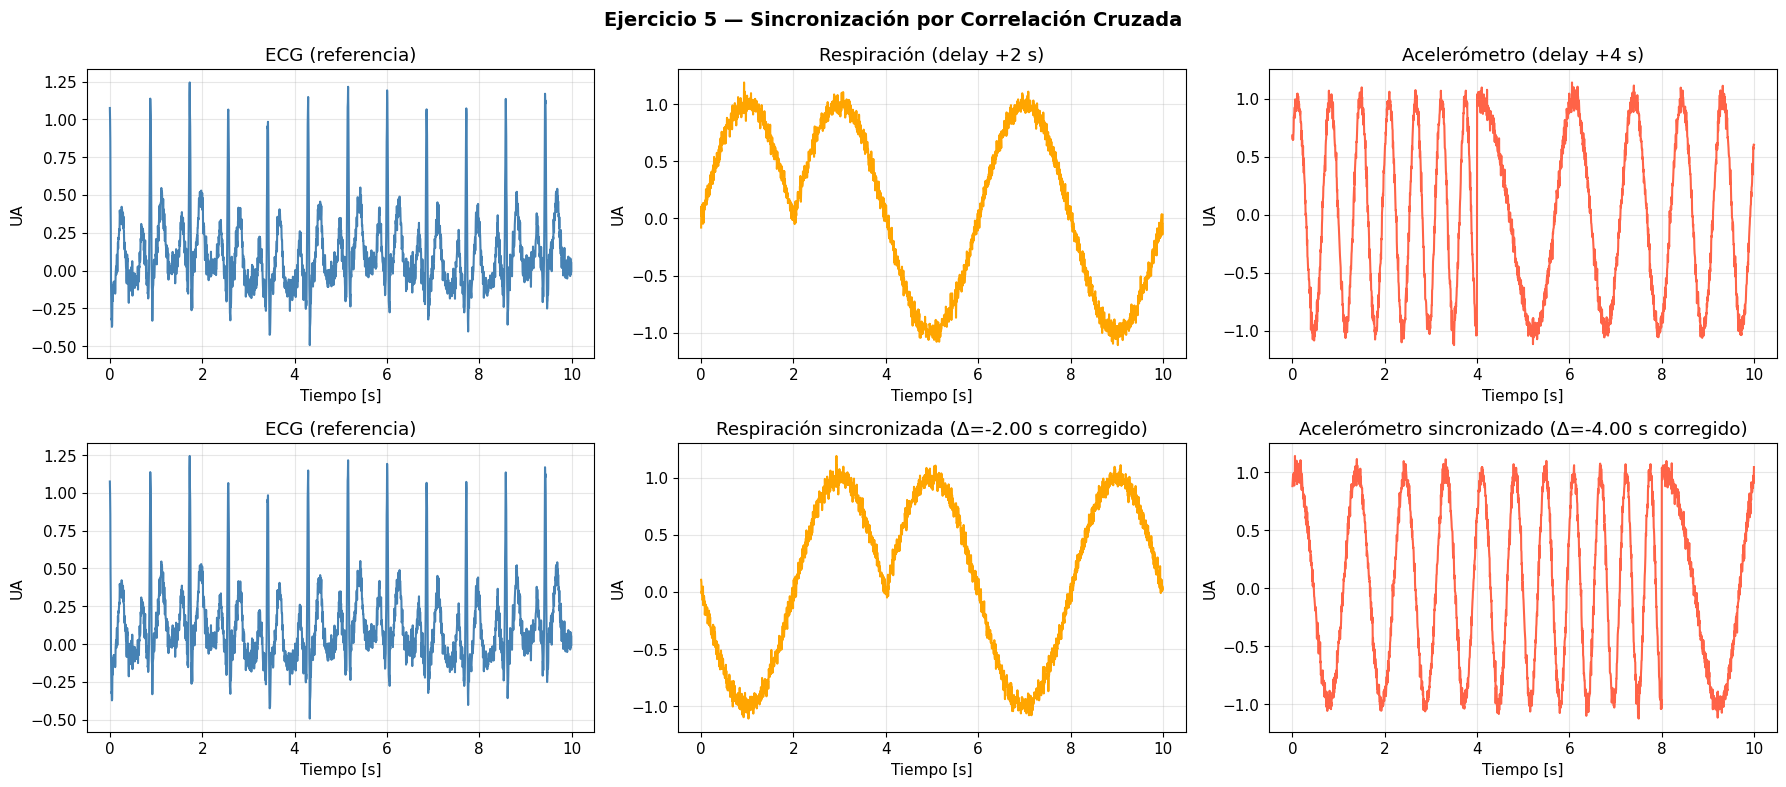

La correlación cruzada estima correctamente los delays.


In [28]:
from scipy.signal import chirp
# Parámetros
fs_sync  = 200
dur_sync = 10
N_sync   = int(fs_sync * dur_sync)
t_sync   = np.linspace(0, dur_sync, N_sync, endpoint=False)

np.random.seed(21)

# Delays reales en muestras
delay_ecg   = 0
delay_resp  = int(2.0 * fs_sync)    # 400 muestras = 2s
delay_accel = int(4.0 * fs_sync)    # 800 muestras = 4s

# Señales base
ecg_base   = nk.ecg_simulate(duration=dur_sync, sampling_rate=fs_sync, heart_rate=70, noise=0)
resp_base  = np.sin(2 * np.pi * 0.25 * t_sync)
accel_base = chirp(t_sync, f0=0.3, f1=2.0, t1=dur_sync, method='linear')
# Aplicar delays + ruido gaussiano
ecg_d = np.roll(ecg_base, delay_ecg) + np.random.normal(0, 0.05, N_sync)
resp_d = np.roll(resp_base, delay_resp) + np.random.normal(0, 0.05, N_sync)
accel_d = np.roll(accel_base, delay_accel) + np.random.normal(0, 0.05, N_sync)

# Función para estimar delay
def estimate_delay(ref, sig):
    corr  = correlate(ref, sig, mode='full')
    lags  = np.arange(-(len(ref)-1), len(ref))
    delay = lags[np.argmax(corr)]
    return delay

# Estimar y corregir delays
d_resp  = estimate_delay(resp_base,  resp_d)
d_accel = estimate_delay(accel_base, accel_d)

print(f'Delay estimado — Respiración  : {d_resp:+d} muestras '
      f'({d_resp/fs_sync:+.2f} s)| Real: {delay_resp} muestras')
print(f'Delay estimado — Acelerómetro : {d_accel:+d} muestras '
      f'({d_accel/fs_sync:+.2f} s) | Real: {delay_accel} muestras')

resp_sync  = np.roll(resp_d, -d_resp)
accel_sync = np.roll(accel_d, -d_accel)

# Visualización
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle('Ejercicio 5 — Sincronización por Correlación Cruzada', fontsize=14, fontweight='bold')

# Fila 0: señales desincronizadas
axes[0, 0].plot(t_sync, ecg_d, color='steelblue')
axes[0, 0].set_title('ECG (referencia)')

axes[0, 1].plot(t_sync, resp_d, color='orange')
axes[0, 1].set_title('Respiración (delay +2 s)')

axes[0, 2].plot(t_sync, accel_d, color='tomato')
axes[0, 2].set_title('Acelerómetro (delay +4 s)')

# Fila 1: señales sincronizadas
axes[1, 0].plot(t_sync, ecg_d,    color='steelblue')
axes[1, 0].set_title('ECG (referencia)')

axes[1, 1].plot(t_sync, resp_sync,  color='orange')
axes[1, 1].set_title(f'Respiración sincronizada ' f'(Δ={d_resp/fs_sync:.2f} s corregido)')

axes[1, 2].plot(t_sync, accel_sync, color='tomato')
axes[1, 2].set_title(f'Acelerómetro sincronizado ' f'(Δ={d_accel/fs_sync:.2f} s corregido)')

for ax in axes.flat:
    ax.set_xlabel('Tiempo [s]')
    ax.set_ylabel('UA')

plt.tight_layout()
plt.show()
print('La correlación cruzada estima correctamente los delays.')

# **Ejercicio 6**

── Longitudes ORIGINALES ──────────────────────────────
ECG :  2500 muestras @ 500 Hz
Resp :   500 muestras @ 100 Hz
Accel :  1000 muestras @ 200 Hz

── Longitudes tras RESAMPLING ─────────────────────────
ECG :  2500 muestras  @ 500 Hz (sin cambio)
Resp :  2500 muestras  @ 500 Hz (↑ upsampling ×5)
Accel :  2500 muestras  @ 500 Hz (↑ upsampling ×2.5)


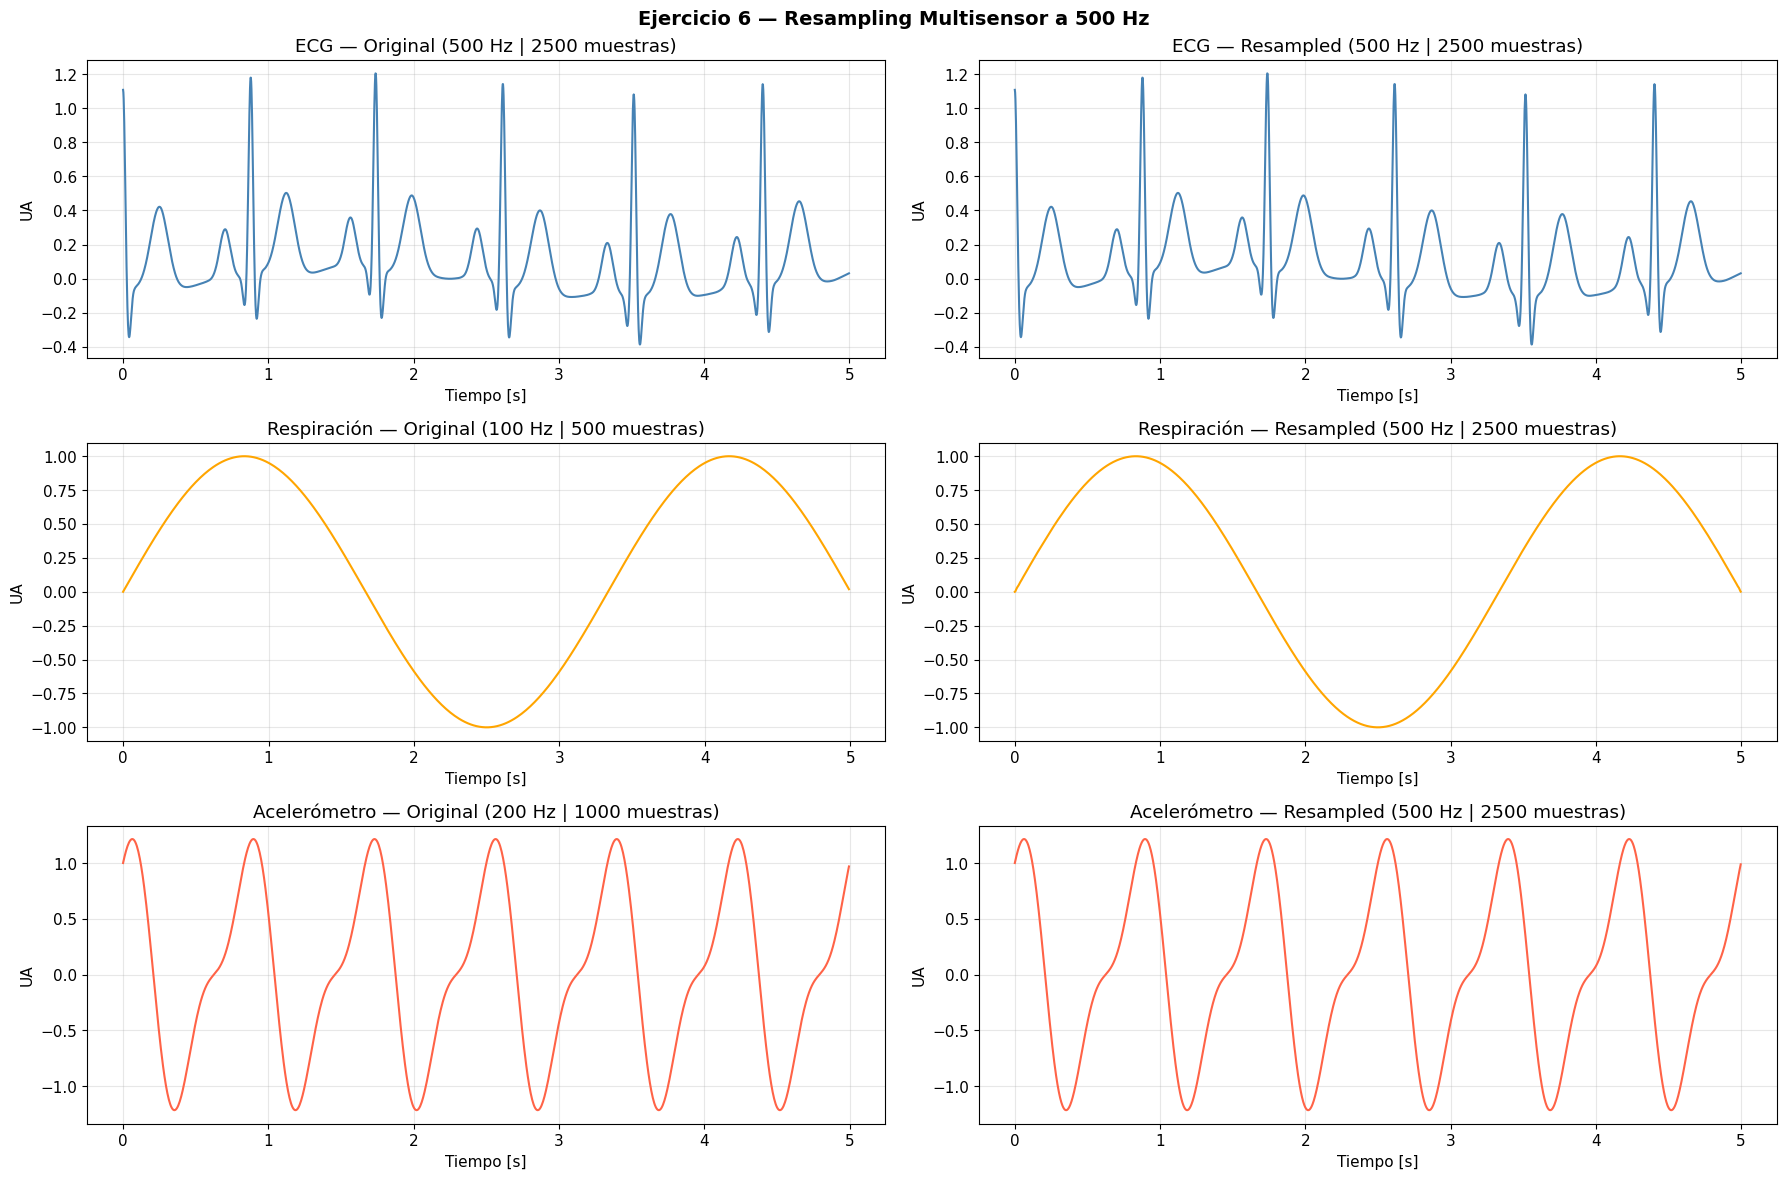


── Matriz de fusión ───────────────────────────────────
Shape: (2500, 3)  →  2500 instantes × 3 sensores
Columnas: [ECG | Respiración | Acelerómetro] — todos a 500 Hz ✓


In [30]:
# Parámetros
fs_ecg_r   = 500
fs_resp_r  = 100
fs_accel_r = 200
fs_target  = 500
dur_rs     = 5

# Ejes de tiempo para cada sensor
t_ecg_r = np.linspace(0, dur_rs, int(fs_ecg_r * dur_rs), endpoint=False)
t_resp_r = np.linspace(0, dur_rs, int(fs_resp_r * dur_rs), endpoint=False)
t_accel_r = np.linspace(0, dur_rs, int(fs_accel_r * dur_rs), endpoint=False)

# Señales en sus propias frecuencias de muestreo
ecg_rs = nk.ecg_simulate(duration=dur_rs, sampling_rate=fs_ecg_r, heart_rate=68, noise=0.01)
resp_rs = np.sin(2 * np.pi * 0.3 * t_resp_r)
accel_rs = (np.cos(2 * np.pi * 1.2 * t_accel_r) + 0.4 * np.sin(2 * np.pi * 2.4 * t_accel_r))

print('── Longitudes ORIGINALES ──────────────────────────────')
print(f'ECG : {len(ecg_rs):>5} muestras @ {fs_ecg_r} Hz')
print(f'Resp : {len(resp_rs):>5} muestras @ {fs_resp_r} Hz')
print(f'Accel : {len(accel_rs):>5} muestras @ {fs_accel_r} Hz')

# Resampling a fs_target = 500 Hz
N_target = int(fs_target * dur_rs) # 2500 muestras
resp_re = resample(resp_rs,  N_target)
accel_re = resample(accel_rs, N_target)
# ECG ya está a 500 Hz → no necesita resampling

t_target = np.linspace(0, dur_rs, N_target, endpoint=False)

print('\n── Longitudes tras RESAMPLING ─────────────────────────')
print(f'ECG : {len(ecg_rs):>5} muestras  @ {fs_target} Hz (sin cambio)')
print(f'Resp : {len(resp_re):>5} muestras  @ {fs_target} Hz (↑ upsampling ×5)')
print(f'Accel : {len(accel_re):>5} muestras  @ {fs_target} Hz (↑ upsampling ×2.5)')

# Visualización
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
fig.suptitle('Ejercicio 6 — Resampling Multisensor a 500 Hz', fontsize=14, fontweight='bold')

# Columna izquierda: señales originales
axes[0, 0].plot(t_ecg_r, ecg_rs, color='steelblue')
axes[0, 0].set_title(f'ECG — Original ({fs_ecg_r} Hz | {len(ecg_rs)} muestras)')

axes[1, 0].plot(t_resp_r, resp_rs, color='orange')
axes[1, 0].set_title(f'Respiración — Original ({fs_resp_r} Hz | {len(resp_rs)} muestras)')

axes[2, 0].plot(t_accel_r, accel_rs, color='tomato')
axes[2, 0].set_title(f'Acelerómetro — Original ({fs_accel_r} Hz | {len(accel_rs)} muestras)')

# Columna derecha: señales a 500 Hz
axes[0, 1].plot(t_target, ecg_rs, color='steelblue')
axes[0, 1].set_title(f'ECG — Resampled ({fs_target} Hz | {len(ecg_rs)} muestras)')

axes[1, 1].plot(t_target, resp_re,  color='orange')
axes[1, 1].set_title(f'Respiración — Resampled ({fs_target} Hz | {len(resp_re)} muestras)')

axes[2, 1].plot(t_target, accel_re, color='tomato')
axes[2, 1].set_title(f'Acelerómetro — Resampled ({fs_target} Hz | {len(accel_re)} muestras)')

for ax in axes.flat:
    ax.set_xlabel('Tiempo [s]')
    ax.set_ylabel('UA')

plt.tight_layout()
plt.show()

# Matriz de fusión final
fusion = np.column_stack([ecg_rs, resp_re, accel_re])
print(f'\n── Matriz de fusión ───────────────────────────────────')
print(f'Shape: {fusion.shape}  →  {fusion.shape[0]} instantes × {fusion.shape[1]} sensores')
print(f'Columnas: [ECG | Respiración | Acelerómetro] — todos a {fs_target} Hz ✓')